In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BOLD = '\033[1m'
END = '\033[0m'

# Data

In [117]:
# Import Data
loan_df = pd.read_csv("./Loan_Data.csv")
loan_df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


In [118]:
# Data Check
print(f"\nSHAPE: {loan_df.shape}")

print("\nDATA TYPE:") 
print(loan_df.dtypes)

print("\nNULL DATA:") 
print(loan_df.isnull().sum())

print("\nDEFAULT DIST:")
print(loan_df['default'].value_counts(normalize=True))


SHAPE: (10000, 8)

DATA TYPE:
customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

NULL DATA:
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

DEFAULT DIST:
default
0    0.8149
1    0.1851
Name: proportion, dtype: float64


In [119]:
loan_df = loan_df.drop('customer_id', axis = 1)
loan_df.columns

Index(['credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

# EDA

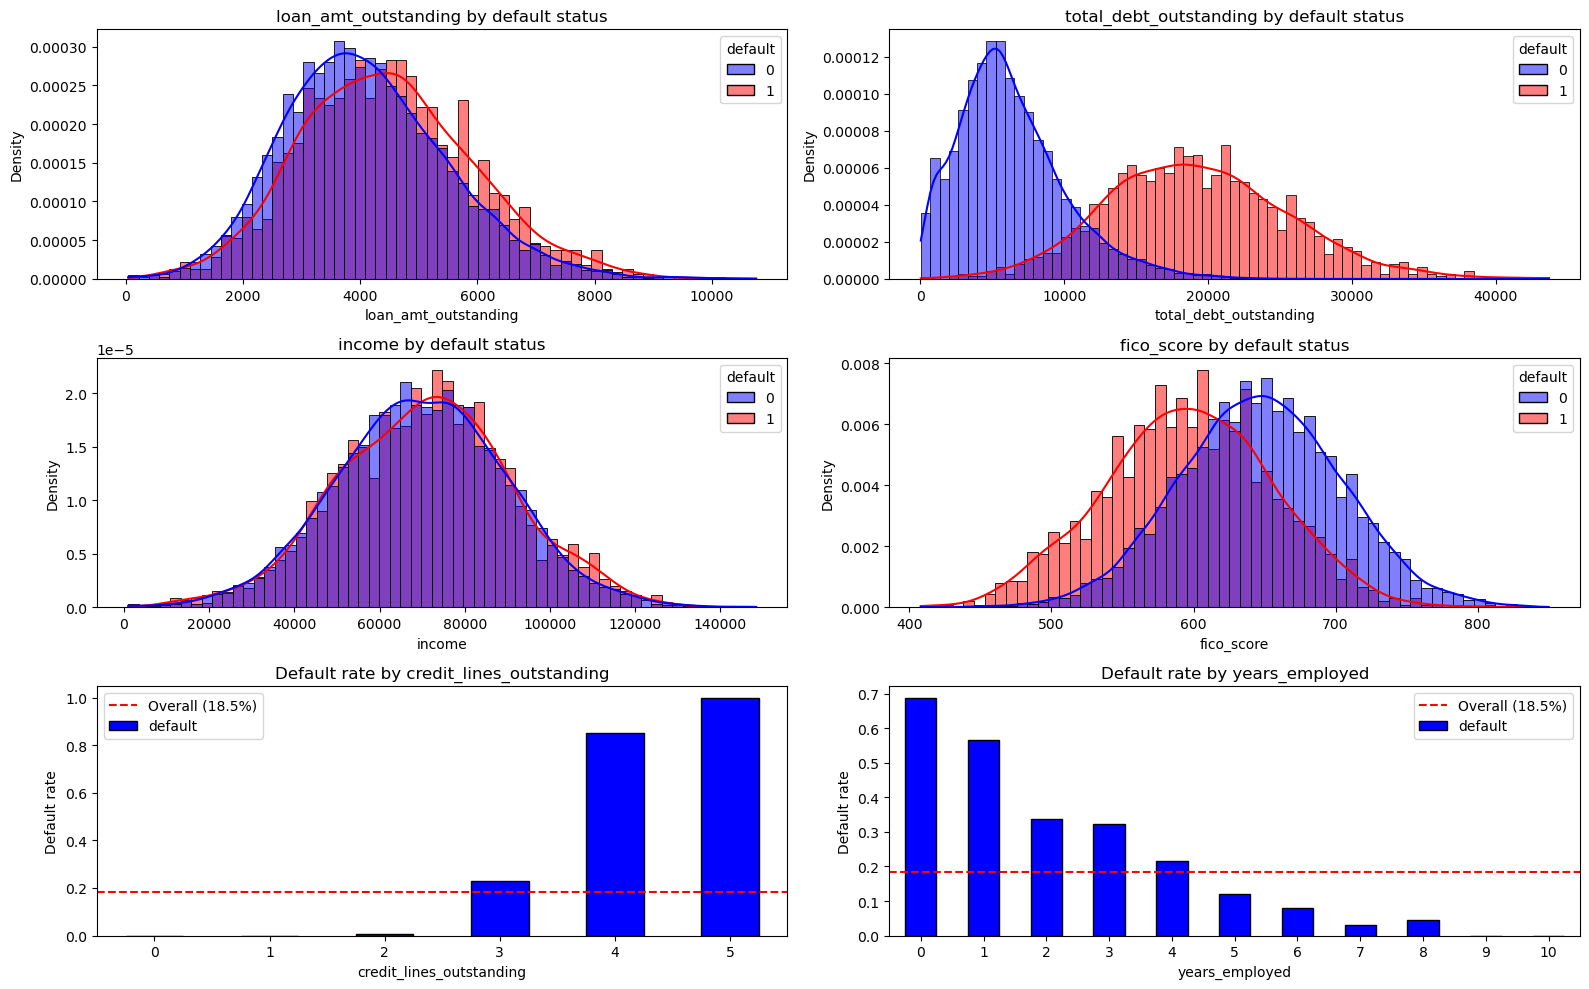

In [120]:
# EDA plots
features = loan_df.drop('default', axis = 1).columns

discrete_features = ['credit_lines_outstanding', 'years_employed']
continuous_features = features.drop(discrete_features).tolist()


fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

# Continuous:
for i, feat in enumerate(continuous_features):
    sns.histplot(data=loan_df, x=feat, hue='default', kde=True,
               stat='density', common_norm=False, ax=axes[i],
               palette={0: 'blue', 1:'red'}, alpha=0.5)
    axes[i].set_title(f"{feat} by default status")
    
# Discrete:
for j, feat in enumerate(discrete_features):
    ax_idx = len(continuous_features) + j
    default_rate = loan_df.groupby(feat)['default'].mean()
    default_rate.plot(kind='bar', ax=axes[ax_idx], color='blue', edgecolor='black', rot=0)
    axes[ax_idx].set_title(f'Default rate by {feat}')
    axes[ax_idx].set_ylabel('Default rate')
    axes[ax_idx].axhline(y=loan_df['default'].mean(), color='red', linestyle='--',
                          label=f'Overall ({loan_df["default"].mean():.1%})')
    axes[ax_idx].legend()

plt.tight_layout()
plt.show()

# Correlation Matrix

In [111]:
# Corr Matrix Calc
corr_matrix = loan_df.corr()
display(corr_matrix.round(2))

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,1.00,0.08,0.85,0.02,-0.09,-0.26,0.86
loan_amt_outstanding,0.08,1.00,0.40,0.84,-0.16,-0.03,0.10
total_debt_outstanding,0.85,0.40,1.00,0.39,-0.17,-0.23,0.76
income,0.02,0.84,0.39,1.00,0.00,-0.01,0.02
years_employed,-0.09,-0.16,-0.17,0.00,1.00,0.26,-0.28
fico_score,-0.26,-0.03,-0.23,-0.01,0.26,1.00,-0.32
default,0.86,0.10,0.76,0.02,-0.28,-0.32,1.00


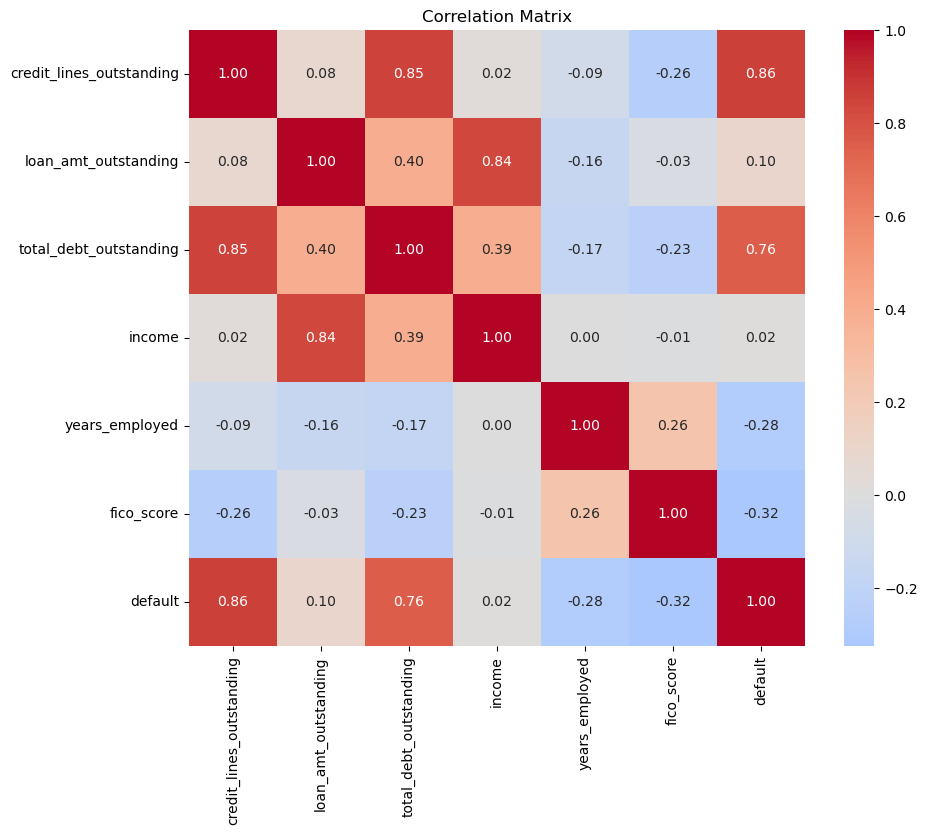

In [112]:
# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm',
           center=0, fmt='.2f', square = True)

plt.title('Correlation Matrix')

plt.show()

In [122]:
# Extract, sorted by strength
target_corr = corr_matrix['default'].drop('default')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print(f"\n{BOLD}Correlations with default (by strength):{END}")
print(target_corr_sorted)

print(f"\n{BOLD}Actual signed correlations:{END}")
print(target_corr.loc[target_corr_sorted.index])


Correlations with default (by strength):
credit_lines_outstanding    0.862815
total_debt_outstanding      0.758868
fico_score                  0.324515
years_employed              0.284506
loan_amt_outstanding        0.098978
income                      0.016309
Name: default, dtype: float64

Actual signed correlations:
credit_lines_outstanding    0.862815
total_debt_outstanding      0.758868
fico_score                 -0.324515
years_employed             -0.284506
loan_amt_outstanding        0.098978
income                      0.016309
Name: default, dtype: float64


In [129]:
# Find redundant pairs
threshold = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
display(upper)

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > threshold
]

print("\nPairs with |corr| > 0.85:")
for pair in high_corr_pairs:
    print(pair)

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,NaN,0.080249,0.852210,0.022272,-0.087900,-0.258177,0.862815
loan_amt_outstanding,NaN,NaN,0.397403,0.835815,-0.158416,-0.031373,0.098978
total_debt_outstanding,NaN,NaN,NaN,0.394397,-0.174353,-0.232246,0.758868
income,NaN,NaN,NaN,NaN,0.001814,-0.010528,0.016309
years_employed,NaN,NaN,NaN,NaN,NaN,0.255873,-0.284506
fico_score,NaN,NaN,NaN,NaN,NaN,NaN,-0.324515
default,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Pairs with |corr| > 0.85:
('total_debt_outstanding', 'credit_lines_outstanding', 0.8522099501162153)
('default', 'credit_lines_outstanding', 0.8628152536592055)


# Ratio Features

In [ ]:
# Create ratio features
loan_df['debt_to_income'] = loan_df['total_debt_outstanding'] / loan_df['income']
loan_df['loan_to_income'] = loan_df['loan_amt_outstanding'] / loan_df['income']

# Quick sanity check — no infinities or NaN from division
print("Any NaN in new features?")
print(loan_df[['debt_to_income', 'loan_to_income']].isnull().sum())
print("\nAny infinities?")
print(np.isinf(loan_df[['debt_to_income', 'loan_to_income']]).sum())

# Summary stats for the new features
print("\nNew feature stats:")
print(loan_df[['debt_to_income', 'loan_to_income']].describe())

# Re-check correlation with default
new_corr = loan_df.corr()['default'].drop('default')
new_corr_sorted = new_corr.abs().sort_values(ascending=False)
print("\nUpdated correlations with default (by strength):")
print(new_corr_sorted)

print("\nSigned correlations:")
print(new_corr.loc[new_corr_sorted.index])